In [5]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# 1. Load the dataset (Assuming the standard Kaggle dataset structure)
# The dataset has 'Time', 'Amount', 'Class' (0=Valid, 1=Fraud), and V1-V28 PCA components.
df = pd.read_excel("default_credit.xls")

# 2. Handle extreme class imbalance and size limitations for DBSCAN
# DBSCAN can be slow on huge datasets. We sample the normal data but keep all fraud data.
fraud = df[df['Class'] == 1]
valid = df[df['Class'] == 0].sample(n=10000, random_state=42) # Sample 10k normal rows
df_sampled = pd.concat([valid, fraud]).sample(frac=1, random_state=42).reset_index(drop=True)

# Separate features and true labels
X = df_sampled.drop(columns=['Class'])
y_true = df_sampled['Class']

# 3. Scale the features
# Crucial step: DBSCAN relies heavily on Euclidean distance calculations!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Initialize and fit DBSCAN
# eps: Maximum distance between two samples to be considered in the same neighborhood
# min_samples: Minimum points in a neighborhood to form a core point
dbscan = DBSCAN(eps=3.0, min_samples=10, n_jobs=-1)
clusters = dbscan.fit_predict(X_scaled)

# 5. Interpret DBSCAN output for Anomaly Detection
# DBSCAN marks outliers/noise as -1. We map these outliers as predicted fraud.
# Normal clusters (0, 1, 2...) are mapped as predicted valid (0).
y_pred = np.where(clusters == -1, 1, 0)

# 6. Evaluate performance
print("--- Confusion Matrix ---")
print(confusion_matrix(y_true, y_pred))

print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=['Valid', 'Fraud']))

# Calculate percentage of actual fraud caught by outliers
outliers_count = np.sum(clusters == -1)
print(f"Total anomalies flagged by DBSCAN: {outliers_count}")


--- Confusion Matrix ---
[[9236  764]
 [6332  304]]

--- Classification Report ---
              precision    recall  f1-score   support

       Valid       0.59      0.92      0.72     10000
       Fraud       0.28      0.05      0.08      6636

    accuracy                           0.57     16636
   macro avg       0.44      0.48      0.40     16636
weighted avg       0.47      0.57      0.47     16636

Total anomalies flagged by DBSCAN: 1068


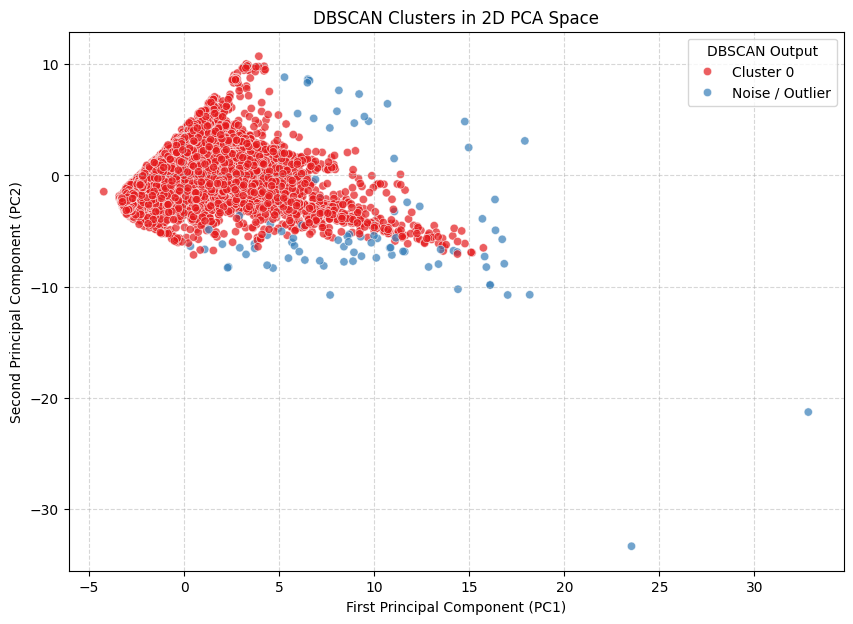

/tmp/ipykernel_3032/2320221258.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Set1', len(unique_labels))


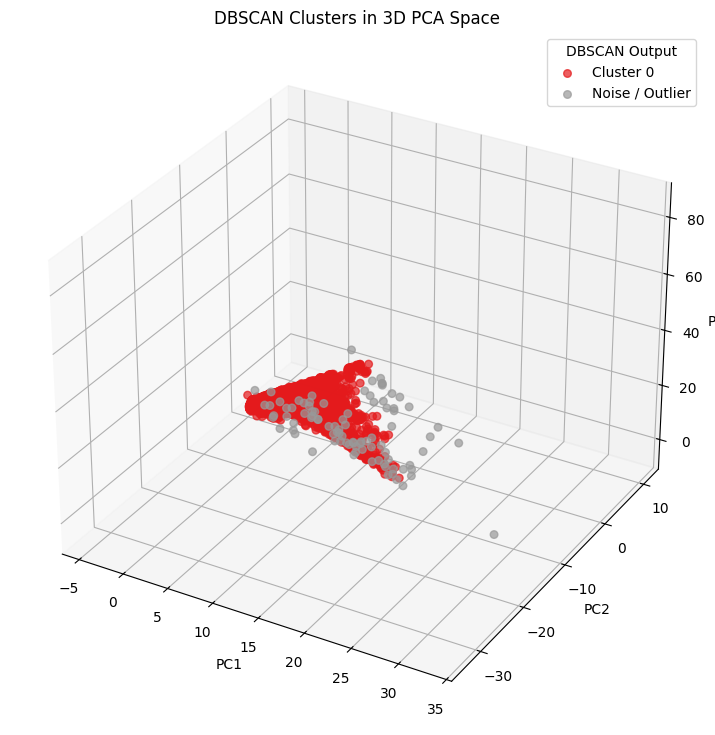

In [8]:

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
# 3. Apply PCA (Reduce to 3 Principal Components for the 3D plot)
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Convert to DataFrame for easier plotting
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2', 'PC3'])

# 4. Apply DBSCAN on the PCA-reduced space
# Running DBSCAN on lower dimensions often speeds up distance calculations
dbscan = DBSCAN(eps=1.5, min_samples=10, n_jobs=-1)
pca_df['Cluster'] = dbscan.fit_predict(X_pca)

# Label anomalies (-1) vs core dense clusters (>= 0)
# We convert to string format so matplotlib treats it as discrete categories in the legend
pca_df['Cluster_Label'] = pca_df['Cluster'].apply(lambda x: 'Noise / Outlier' if x == -1 else f'Cluster {x}')

# ==========================================
# 5. 2D PLOT (Using Principal Component 1 & 2)
# ==========================================
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='Cluster_Label',
    data=pca_df,
    palette='Set1',
    alpha=0.7
)
plt.title('DBSCAN Clusters in 2D PCA Space')
plt.xlabel('First Principal Component (PC1)')
plt.ylabel('Second Principal Component (PC2)')
plt.legend(title='DBSCAN Output')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# ==========================================
# 6. 3D PLOT (Using Principal Component 1, 2, & 3)
# ==========================================
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Get unique labels for custom color mapping in 3D
unique_labels = pca_df['Cluster_Label'].unique()
colors = plt.cm.get_cmap('Set1', len(unique_labels))

for i, label in enumerate(unique_labels):
    subset = pca_df[pca_df['Cluster_Label'] == label]
    ax.scatter(
        subset['PC1'], subset['PC2'], subset['PC3'],
        label=label,
        s=30,
        alpha=0.7,
        c=[colors(i)]
    )

ax.set_title('DBSCAN Clusters in 3D PCA Space')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.legend(title='DBSCAN Output')
plt.show()


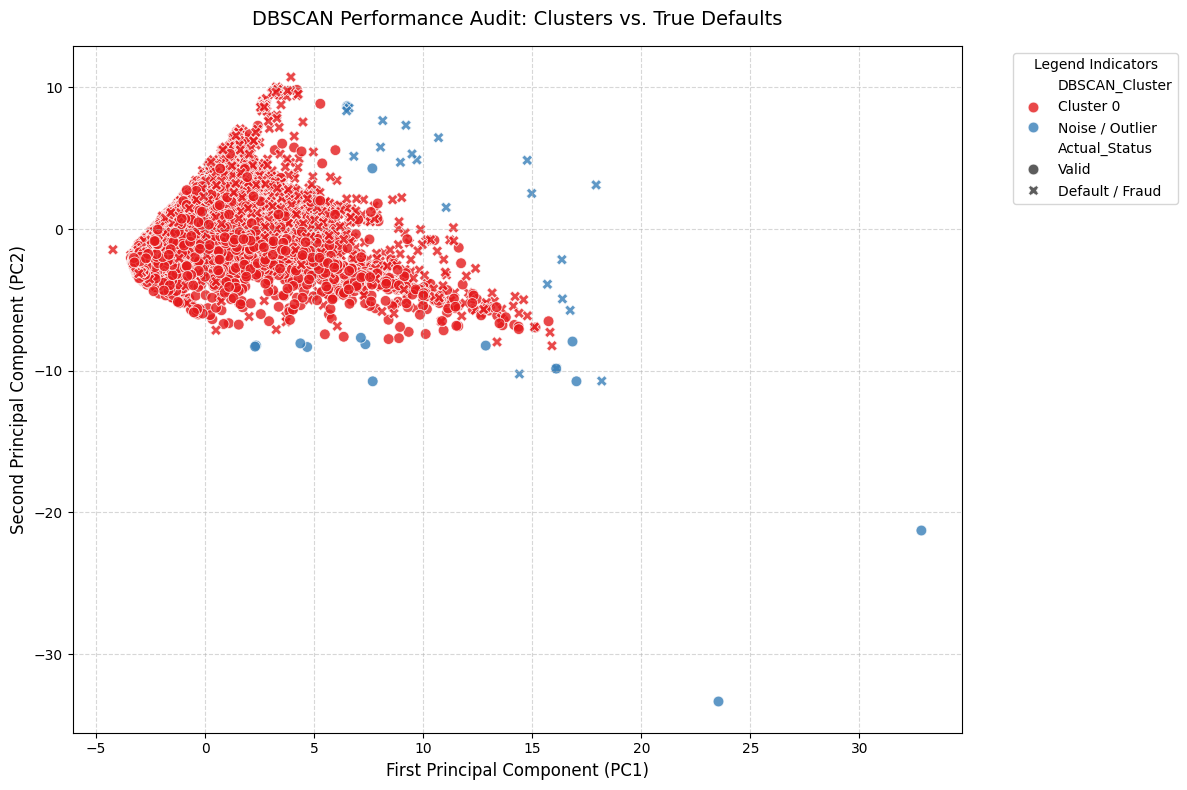

In [9]:
#differentiate DBSCAN outliers from true defaults


# 2. Reduce dimensions via PCA
X_pca = PCA(n_components=2).fit_transform(X_scaled) # 2D representation

# 3. Create a plotting DataFrame
plot_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])

# Map actual targets to clear text labels
plot_df['Actual_Status'] = y_true.values
plot_df['Actual_Status'] = plot_df['Actual_Status'].map({0: 'Valid', 1: 'Default / Fraud'})

# 4. Fit DBSCAN on PCA space
dbscan = DBSCAN(eps=1.5, min_samples=10, n_jobs=-1)
clusters = dbscan.fit_predict(X_pca)
plot_df['DBSCAN_Cluster'] = np.where(clusters == -1, 'Noise / Outlier', f'Cluster {clusters}')
# Fix string representation for discrete mapping
plot_df['DBSCAN_Cluster'] = [f'Cluster {c}' if c >= 0 else 'Noise / Outlier' for c in clusters]

# ==========================================================
# 5. OVERLAY PLOT: Colors = Clusters, Shapes = True Status
# ==========================================================
plt.figure(figsize=(12, 8))

# Define explicit markers for True Status (Valid = circle, Fraud = X)
marker_mapping = {'Valid': 'o', 'Default / Fraud': 'X'}

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='DBSCAN_Cluster',   # Color determined by DBSCAN
    style='Actual_Status',  # Shape determined by True Class
    markers=marker_mapping,
    data=plot_df,
    palette='Set1',         # Distinct colors for clusters vs noise
    s=60,                   # Point size
    alpha=0.8
)

plt.title('DBSCAN Performance Audit: Clusters vs. True Defaults', fontsize=14, pad=15)
plt.xlabel('First Principal Component (PC1)', fontsize=12)
plt.ylabel('Second Principal Component (PC2)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Place legend outside of the plot box so it doesn't cover data points
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Legend Indicators')
plt.tight_layout()
plt.show()


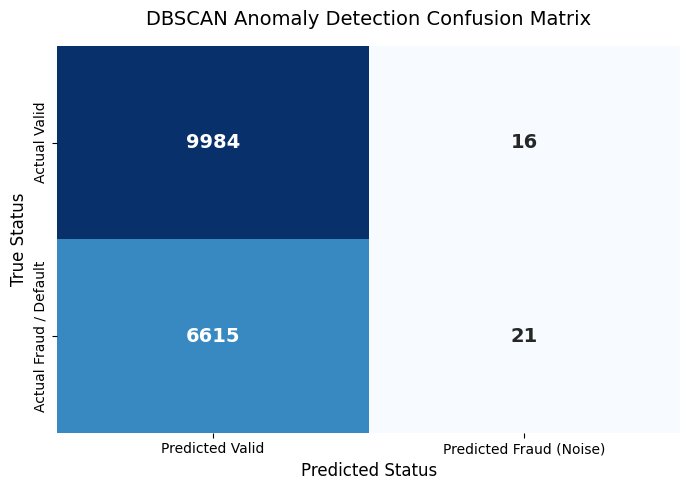

================ PERFORMANCE REPORT ================
               precision    recall  f1-score   support

        Valid       0.60      1.00      0.75     10000
Fraud/Default       0.57      0.00      0.01      6636

     accuracy                           0.60     16636
    macro avg       0.58      0.50      0.38     16636
 weighted avg       0.59      0.60      0.45     16636

Total Fraud/Defaults Caught (True Positives): 21
Total Fraud/Defaults Missed (False Negatives): 6615
DBSCAN Catch Rate (Recall): 0.32%


In [10]:
#confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# 1. Map DBSCAN output to binary classification classes
# If cluster is -1 (Noise), it's predicted as Fraud/Default (1).
# Otherwise (Cluster >= 0), it's predicted as a Valid transaction (0).
y_pred = np.where(clusters == -1, 1, 0)

# 2. Compute the confusion matrix array
# Structure: [[TN, FP], [FN, TP]]
cm = confusion_matrix(y_true, y_pred)

# 3. Create a clean, visually scannable Heatmap of the matrix
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted Valid', 'Predicted Fraud (Noise)'],
    yticklabels=['Actual Valid', 'Actual Fraud / Default'],
    cbar=False,
    annot_kws={"size": 14, "weight": "bold"}
)

plt.title('DBSCAN Anomaly Detection Confusion Matrix', fontsize=14, pad=15)
plt.ylabel('True Status', fontsize=12)
plt.xlabel('Predicted Status', fontsize=12)
plt.tight_layout()
plt.show()

# 4. Print detailed performance metrics text report
print("================ PERFORMANCE REPORT ================")
print(classification_report(y_true, y_pred, target_names=['Valid', 'Fraud/Default']))

# Print specific breakdown of interest
tn, fp, fn, tp = cm.ravel()
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
print(f"Total Fraud/Defaults Caught (True Positives): {tp}")
print(f"Total Fraud/Defaults Missed (False Negatives): {fn}")
print(f"DBSCAN Catch Rate (Recall): {recall:.2%}")
print("====================================================")
